# Netflix Movies and TV Shows Analysis

Exploratory Data Analysis (EDA) of the Netflix titles dataset.  
This notebook covers data loading, cleaning, exploration, and visualization.


## 1. Import Libraries


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset


In [8]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


## 3. Dataset Overview


In [10]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData Types:")
print(df.dtypes)

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [12]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 4. Missing Values and Duplicates


In [13]:
# Missing values count and percentage
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

,Missing Count,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [14]:
# Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## 5. Data Cleaning

### 5.1 Date Added


In [15]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["added_year"] = df["date_added"].dt.year
df[["date_added", "added_year"]].head()

,date_added,added_year
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [16]:
print("Missing date_added after conversion:", df["date_added"].isnull().sum())

Missing date_added after conversion: 98


### 5.2 Rating


In [17]:
print("Missing ratings:", df["rating"].isnull().sum())
df[df["rating"].isnull()][["type", "title", "rating", "duration"]]

Missing ratings: 4


,type,title,rating,duration
5989,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,37 min
6827,TV Show,Gargantia on the Verdurous Planet,NaN,1 Season
7312,TV Show,Little Lunch,NaN,1 Season
7537,Movie,My Honor Was Loyalty,NaN,115 min


In [18]:
df["rating"] = df["rating"].fillna("Unknown")
print("Missing ratings after fill:", df["rating"].isnull().sum())

Missing ratings after fill: 0


### 5.3 Country


In [19]:
print("Missing countries:", df["country"].isnull().sum())
df["country"] = df["country"].fillna("Unknown")
print("Missing countries after fill:", df["country"].isnull().sum())

Missing countries: 831
Missing countries after fill: 0


### 5.4 Movie Duration


In [20]:
# Extract numeric duration for movies (in minutes)
df["movie_duration"] = df["duration"].str.replace(" min", "", regex=False)
df["movie_duration"] = pd.to_numeric(df["movie_duration"], errors="coerce")
df[["type", "duration", "movie_duration"]].head()

,type,duration,movie_duration
0,Movie,90 min,90.0
1,TV Show,2 Seasons,NaN
2,TV Show,1 Season,NaN
3,TV Show,1 Season,NaN
4,TV Show,2 Seasons,NaN


## 6. Content Type Distribution


In [21]:
print(df["type"].value_counts())
print()
print(df["type"].value_counts(normalize=True).mul(100).round(2))

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


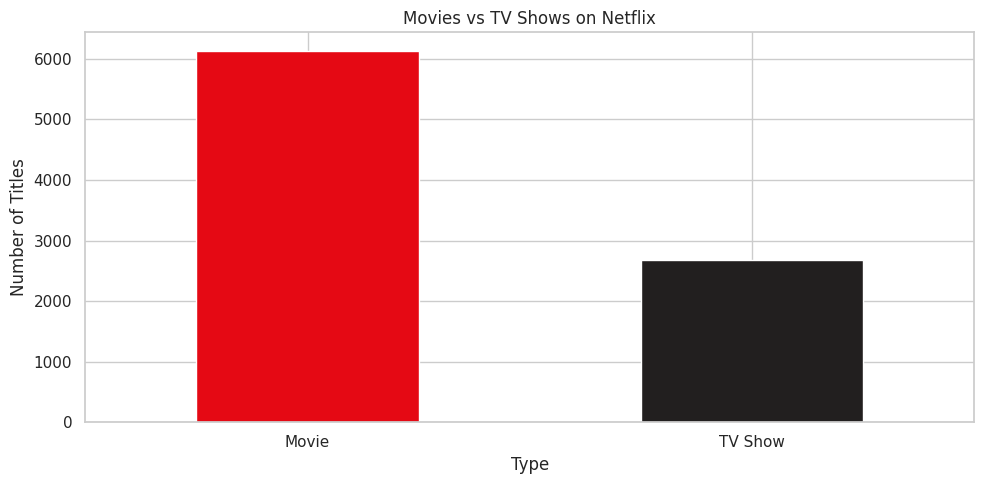

In [22]:
df["type"].value_counts().plot(kind="bar", color=["#E50914", "#221F1F"])
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

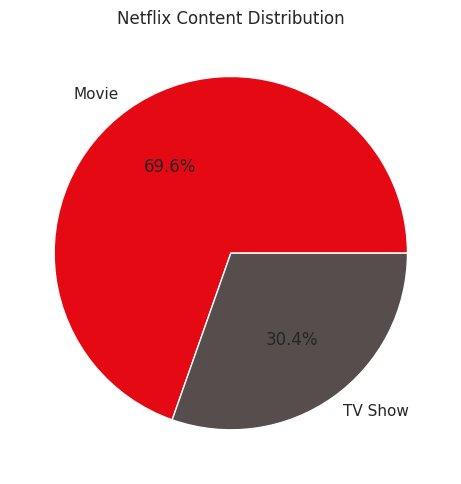

In [25]:
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#E50914", "#564D4D"])
plt.title("Netflix Content Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Top Genres


In [26]:
genres = df["listed_in"].str.split(", ").explode()
print(genres.value_counts().head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


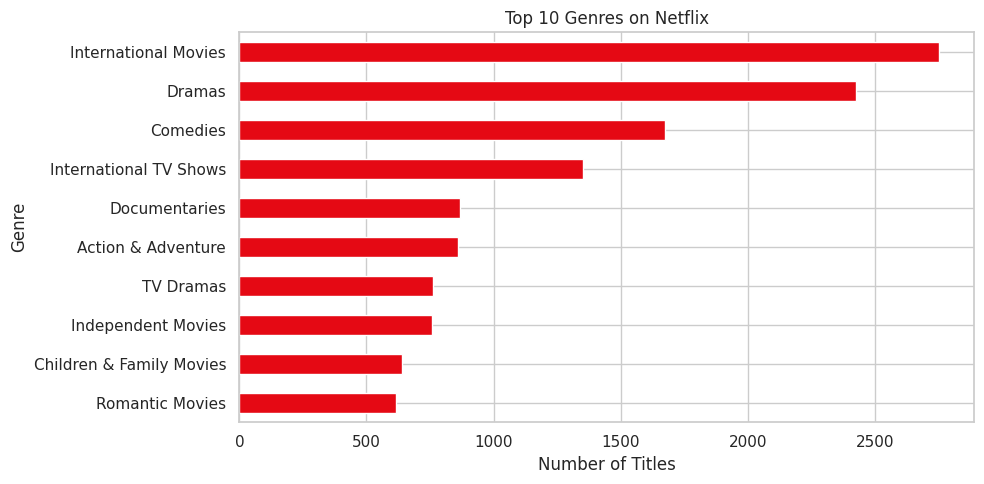

In [27]:
genres.value_counts().head(10).plot(kind="barh", color="#E50914")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Content Added Over Time


In [28]:
print(df["added_year"].value_counts().sort_index())

added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


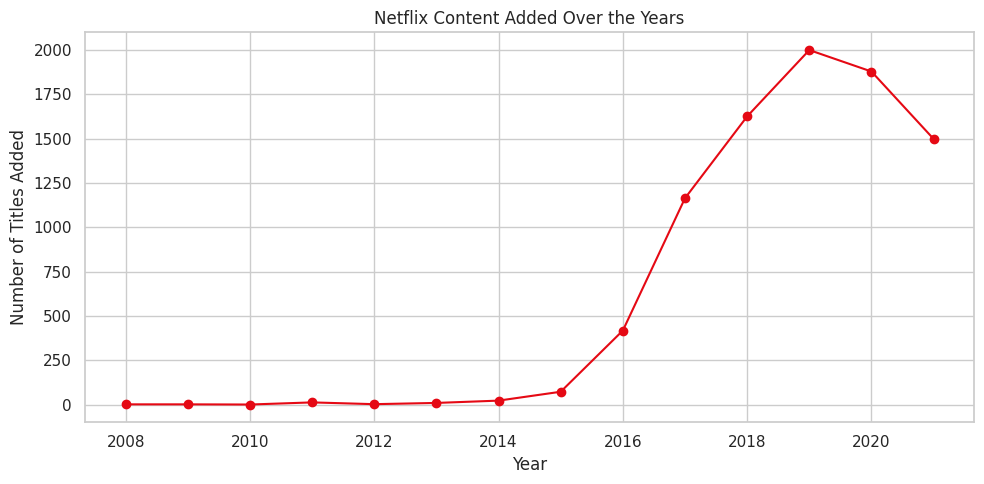

In [29]:
df["added_year"].value_counts().sort_index().plot(kind="line", marker="o", color="#E50914")
plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.show()

## 9. Top Countries


In [30]:
countries = df["country"].str.split(", ").explode()
print(countries.value_counts().head(10))

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


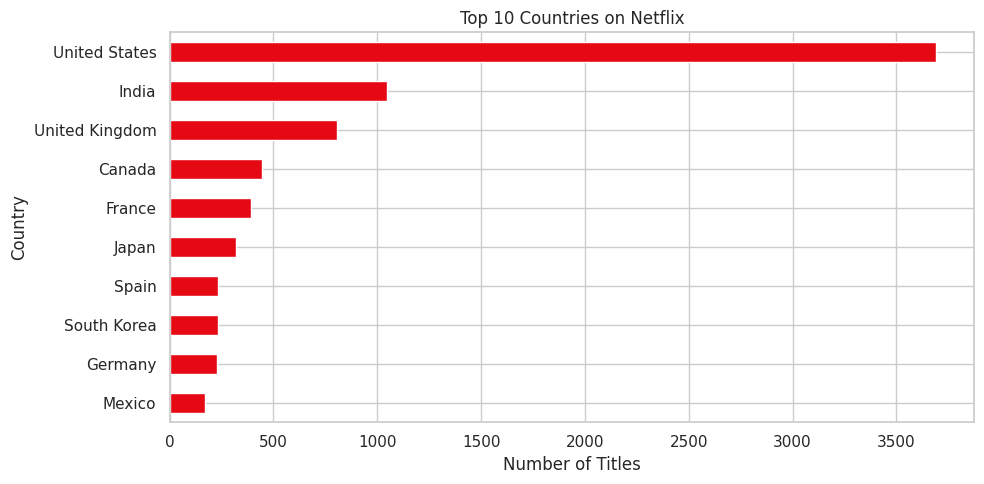

In [31]:
countries.value_counts().drop("Unknown", errors="ignore").head(10).plot(kind="barh", color="#E50914")
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Ratings Analysis


In [32]:
print(df["rating"].value_counts().head(10))

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


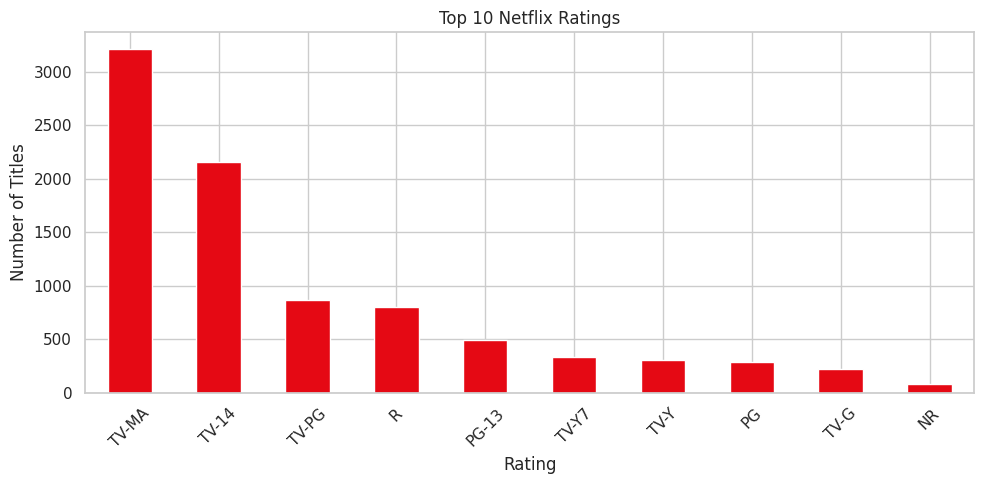

In [33]:
df["rating"].value_counts().head(10).plot(kind="bar", color="#E50914")
plt.title("Top 10 Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
rating_by_type = df.groupby(["rating", "type"]).size().unstack().sort_values("Movie", ascending=False).head(10)
print(rating_by_type)

type     Movie  TV Show
rating                 
TV-MA   2062.0   1145.0
TV-14   1427.0    733.0
R        797.0      2.0
TV-PG    540.0    323.0
PG-13    490.0      NaN
PG       287.0      NaN
TV-Y7    139.0    195.0
TV-Y     131.0    176.0
TV-G     126.0     94.0
NR        75.0      5.0


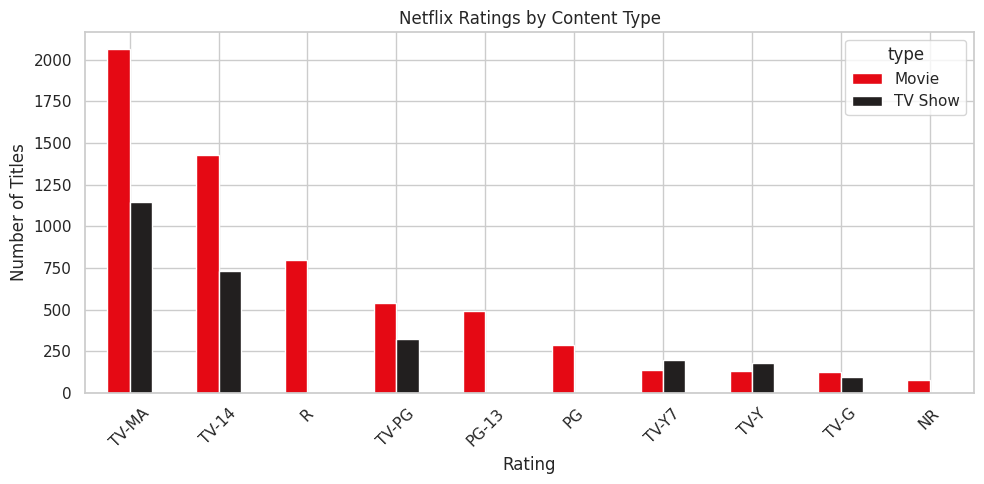

In [35]:
rating_by_type.plot(kind="bar", color=["#E50914", "#221F1F"])
plt.title("Netflix Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Movie Duration Analysis


In [36]:
movie_dur = df.loc[df["type"] == "Movie", "movie_duration"].dropna()
print("Mean duration (minutes):", round(movie_dur.mean(), 2))
print("Median duration (minutes):", round(movie_dur.median(), 2))
print("Min duration:", movie_dur.min())
print("Max duration:", movie_dur.max())

Mean duration (minutes): 99.58
Median duration (minutes): 98.0
Min duration: 3.0
Max duration: 312.0


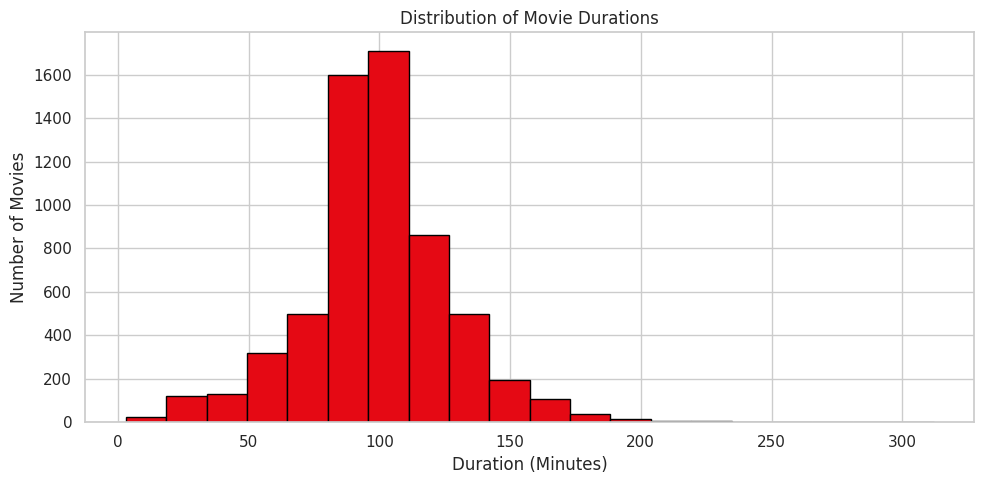

In [37]:
movie_dur.plot(kind="hist", bins=20, color="#E50914", edgecolor="black")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

## 12. Release Year Trends


In [38]:
print(df["release_year"].value_counts().sort_index().tail(15))

release_year
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


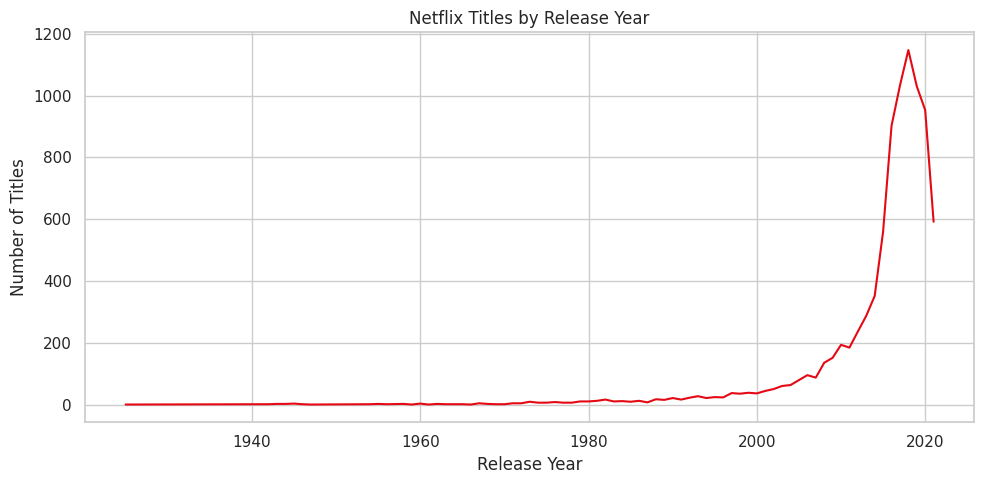

In [39]:
df["release_year"].value_counts().sort_index().plot(kind="line", color="#E50914")
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

In [40]:
year_type = df.groupby(["release_year", "type"]).size().unstack().tail(15)
print(year_type)

type          Movie  TV Show
release_year                
2007           74.0     14.0
2008          113.0     23.0
2009          118.0     34.0
2010          154.0     40.0
2011          145.0     40.0
2012          173.0     64.0
2013          225.0     63.0
2014          264.0     88.0
2015          398.0    162.0
2016          658.0    244.0
2017          767.0    265.0
2018          767.0    380.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0


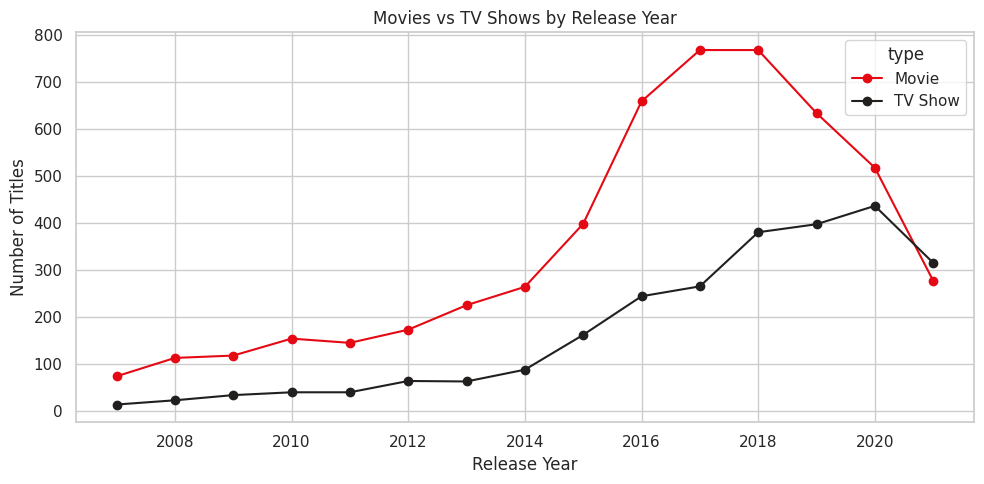

In [41]:
year_type.plot(kind="line", marker="o", color=["#E50914", "#221F1F"])
plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

## 13. Correlation Analysis

Correlation between release year and movie duration.


In [42]:
corr = df[["release_year", "movie_duration"]].corr()
corr

,release_year,movie_duration
release_year,1.000000,-0.206285
movie_duration,-0.206285,1.000000


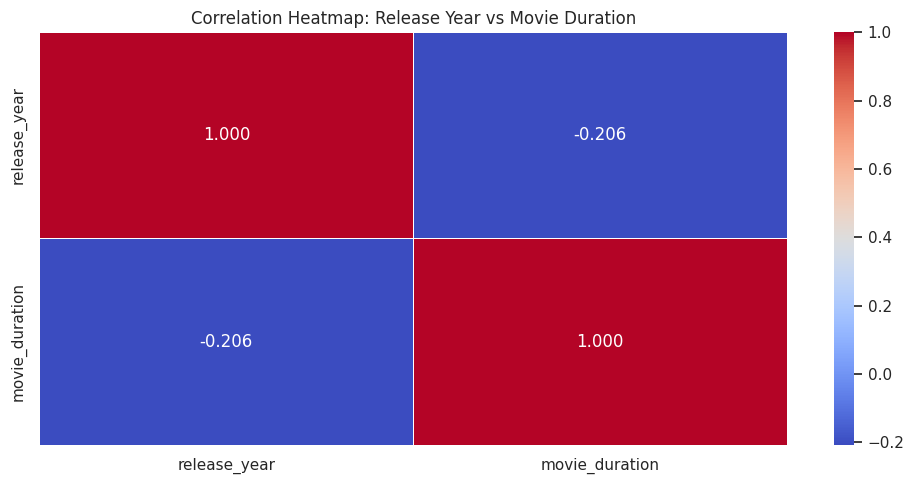

In [43]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5)
plt.title("Correlation Heatmap: Release Year vs Movie Duration")
plt.tight_layout()
plt.show()

## 14. Key Insights

- The dataset contains both **Movies** and **TV Shows**, with Movies making up the majority of titles.
- Content addition on Netflix has grown significantly in recent years.
- Popular genres include International Movies, Dramas, and Comedies.
- The United States and India are among the top content-producing countries.
- Most common ratings are TV-MA and TV-14.
- Movie durations are typically around 90–100 minutes on average.
- There is a weak negative correlation between release year and movie duration (newer movies tend to be slightly shorter).
